### 📊 COMPRENSIÓN EDA - PROYECTO INTEGRADOR

**Modelo Predictivo de Riesgo Crediticio**

DESPLIEGUE DE PROYECTO (RESUMEN DEL PROYECTO):

**1. Contexto del Proyecto**
Rol de Científico de Datos Junior Advanced dentro del equipo de Datos y Analítica de la entidad financiera, el objetivo principal de este proyecto es desarrollar, evaluar y desplegar un modelo de aprendizaje automático (Machine Learning).

Este modelo utilizará información histórica sobre la colocación y comportamiento de créditos con el fin de anticiparse al riesgo operativo y predecir la probabilidad de pago oportuno de nuevos solicitantes.

**2. Diccionario y Caracterización de Datos en nuestra base de datos**
A continuación se detalla la estructura inicial de las 23 variables disponibles en el dataset para el Análisis Exploratorio de Datos (EDA):

### 📖 Diccionario de Variables del Dataset

* **tipo_credito:** Código numérico que identifica la modalidad o destino del préstamo otorgado.
* **fecha_prestamo:** Marca temporal (fecha y hora) en la que se desembolsó el crédito.
* **capital_prestado:** Monto principal de dinero otorgado al cliente en el préstamo.
* **plazo_meses:** Tiempo total pactado en meses para la devolución completa de la deuda.
* **edad_cliente:** Edad cronológica del titular de la solicitud (en años).
* **tipo_laboral:** Condición u ocupación laboral reportada por el solicitante (ej. Empleado, Independiente).
* **salario_cliente:** Ingreso mensual de fuente laboral reportado por el titular.
* **total_otros_prestamos:** Suma monetaria consolidada de otras obligaciones financieras vigentes.
* **cuota_pactada:** Valor del pago periódico mensual acordado para saldar la deuda.
* **puntaje:** Scoring o calificación interna de riesgo crediticio asignada por la entidad financiera.
* **puntaje_datacredito:** Calificación de riesgo externa generada por la central de información crediticia (Buró).
* **cant_creditosvigentes:** Número total de obligaciones o préstamos activos en el sistema al momento del análisis.
* **huella_consulta:** Cantidad de veces que las entidades financieras han consultado el historial crediticio del cliente en periodos recientes.
* **saldo_mora:** Monto dinerario correspondiente a pagos vencidos y no efectuados a la fecha.
* **saldo_total:** Deuda global pendiente (incluye capital restante, moras e intereses).
* **saldo_principal:** Remanente del capital inicial otorgado que aún no se ha amortizado.
* **saldo_mora_codeudor:** Saldo vencido en obligaciones donde el titular figura como aval o codeudor de un tercero.
* **creditos_sectorFinanciero:** Cantidad de créditos activos contratados con bancos y corporaciones financieras.
* **creditos_sectorCooperativo:** Número de obligaciones vigentes mantenidas con el sector cooperativo.
* **creditos_sectorReal:** Número de productos a crédito con empresas del sector comercial o de servicios.
* **promedio_ingresos_datacredito:** Estimación del ingreso mensual promedio del cliente según registros de centrales de riesgo.
* **tendencia_ingresos:** Indicador cualitativo sobre el comportamiento temporal de los ingresos (ej. Creciente, Estable, Decreciente).
* **Pago_atiempo:** **Variable Objetivo (Target)**. Indica el cumplimiento puntual del plan de pagos (`1` = Pago oportuno, `0` = Incumplimiento o mora).

### 📋 Caracterización y Estado Actual de los Datos (10,763 Registros)

| Columna | Tipo en Python | Naturaleza Teórica | Estado / Observación |
| :--- | :--- | :--- | :--- |
| **tipo_credito** | `int64` | Categórica (Nominal) | Viene codificada numéricamente. |
| **fecha_prestamo** | `datetime64[us]` | Temporal | Correctamente casteada como fecha. |
| **capital_prestado** | `float64` | Numérica (Continua) | Completa (sin nulos). |
| **plazo_meses** | `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **edad_cliente** | `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **tipo_laboral** | `str` | Categórica (Nominal) | Tipo texto/cadena. |
| **salario_cliente** | `int64` | Numérica (Continua) | Completa (sin nulos). |
| **total_otros_prestamos**| `int64` | Numérica (Continua) | Completa (sin nulos). |
| **cuota_pactada** | `int64` | Numérica (Continua) | Completa (sin nulos). |
| **puntaje** | `float64` | Numérica (Continua) | Score interno completo. |
| **puntaje_datacredito** | `float64` | Numérica (Continua) | Contiene 6 nulos. |
| **cant_creditosvigentes**| `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **huella_consulta** | `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **saldo_mora** | `float64` | Numérica (Continua) | Contiene 156 nulos. |
| **saldo_total** | `float64` | Numérica (Continua) | Contiene 156 nulos. |
| **saldo_principal** | `float64` | Numérica (Continua) | Contiene 405 nulos. |
| **saldo_mora_codeudor** | `float64` | Numérica (Continua) | Contiene 590 nulos. |
| **creditos_sectorFinanciero** | `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **creditos_sectorCooperativo** | `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **creditos_sectorReal**| `int64` | Numérica (Discreta) | Completa (sin nulos). |
| **promedio_ingresos_datacredito** | `float64` | Numérica (Continua) | **Crítica:** Presenta 2,930 nulos (~27%). |
| **tendencia_ingresos** | `object` | Categórica (Ordinal) | **Crítica:** Presenta 2,932 nulos (~27%). |
| **Pago_atiempo** | `int64` | Categórica (Dicotómica) | **Variable Objetivo (Target)**. |

### 📚 EDA: IMPORTACIÓN DE LIBRERIAS - BREVE EXPLICACIÓN DEL DATASET

### 🚨 Hallazgos Críticos y Anomalías en el Análisis Estadístico (`describe()`)

Tras la inspección estadística de las variables numéricas, se detectaron los siguientes **valores atípicos (outliers)** y **anomalías de datos** que deben tratarse antes de la fase de modelado:

> ⚠️ **1. Registros de Edad Incoherentes (`edad_cliente`)**
> * **Anomalía:** Se registra un valor máximo de **123 años**.
> * **Diagnóstico:** Inconsistencia biológica, error de digitación o registro obsoleto.
> * **Acción EDA:** Documentar el hallazgo y definir un umbral de filtrado o imputación (ej. acotar a un máximo de 80 u 90 años).

> ⚠️ **2. Scores Crediticios Negativos (`puntaje` y `puntaje_datacredito`)**
> * **Anomalía:** Se observan valores mínimos de **-38** y **-7**.
> * **Diagnóstico:** Los scores financieros son escalas positivas (ej. 150 a 950). Los negativos obedecen a códigos de error del sistema o valores faltantes no tipificados.
> * **Acción EDA:** Tratar estos registros como nulos (`NaN`) para no distorsionar las métricas de scoring.

> ⚠️ **3. Distorsión Extrema en Ingresos (`salario_cliente`)**
> * **Anomalía:** Registra un salario máximo en notación científica (`2.20e+10`), equivalente a **$22.000.000.000** (22 mil millones).
> * **Diagnóstico:** Outlier extremo que destruye la media y la desviación estándar de la variable.
> * **Acción EDA:** Aplicar transformaciones (como escala logarítmica) o remoción de outliers extremos para evitar sesgar el modelo.

> ℹ️ **4. Distribución Asimétrica en Mora (`saldo_mora`)**
> * **Anomalía:** El 75% de los datos muestra un saldo en mora igual a **$0**, mientras que el valor máximo reportado es de **$12.534**.
> * **Diagnóstico:** Comportamiento esperado en cartera sana; la gran mayoría de clientes no presenta mora activa al momento de la toma de datos.

### 📊 Cuadro Resumen de Inspección Numérica

| Variable | Registro Anómalo / Extremo | Naturaleza del Problema | Impacto / Tratamiento |
| :--- | :--- | :--- | :--- |
| **`edad_cliente`** | Máximo: **123 años** | Error de digitación | Filtrar o imputar registro. |
| **`puntaje` / `datacredito`** | Mínimos: **-38 / -7** | Código de falla de sistema | Reemplazar por `NaN` / Imputar. |
| **`salario_cliente`** | Máximo: **$22.000M** | Outlier astronómico | Eliminar outlier / Transformación log. |
| **`saldo_mora`** | Percentil 75%: **$0** | Distribución asimétrica | Normalizar o categorizar la variable. |


In [9]:
# Importación de las librerias para manejo y visualización del Dataset
import numpy as np
import pandas as pd
from IPython.display import display

# Librerias para graficas
import matplotlib.pyplot as plt
import seaborn as sns

print("Cargando DataSet con la función cargarDatos Generada en cargar_datos.py...")

# Realizando la "extracción" del DataSet
from cargar_datos import cargarDatos

# Imprimiendo datos del DataSet
pd.set_option('display.max_columns', None)
df = cargarDatos()
display(df.head())
df.info()

# Visualizando si hay valores o datos incongruentes en el DataSet antes de realizar las graficas
display(df.describe())

Cargando DataSet con la función cargarDatos Generada en cargar_datos.py...
       tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0                 7 2024-12-21 11:31:35         3692160.0           10   
1                 4 2025-04-22 09:47:35          840000.0            6   
2                 9 2026-01-08 12:22:40         5974028.4           10   
3                 4 2025-08-04 12:04:10         1671240.0            6   
4                 9 2025-04-26 11:24:26         2781636.0           11   
...             ...                 ...               ...          ...   
10758             9 2025-01-19 16:18:28         2414886.0           10   
10759             4 2025-01-10 16:40:21         2916000.0           24   
10760             4 2025-06-19 14:28:47         4249200.0           36   
10761             9 2025-03-02 11:53:41         1283307.6           10   
10762             4 2024-12-08 12:46:03         3915000.0           12   

       edad_cliente   tipo_laboral  

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


### 🕵️ EVALUANDO HALLAZGOS Y REALIZANDO LAS GRAFICAS DE EVIDENCIA

### 📌 Resumen Cuantitativo de Hallazgos y Anomalías Detectadas

A continuación se consolidan los conteos exactos de los registros anómalos identificados durante la fase de exploración inicial (EDA):

### 1. Edades Fuera de Rango (`edad_cliente > 90`)
* **Total de registros atípicos:** **150 clientes** (1.39% del dataset).
  * `122 años`: 144 clientes.
  * `121 años`: 4 clientes.
  * `123 años`: 2 clientes.

### 2. Puntajes Crediticios Negativos
* **`puntaje` (Score Interno):** **119 clientes** presentan valores negativos (rangos entre `-0.36` y `-38.0`).
* **`puntaje_datacredito` (Buró):** **1 cliente** presenta un valor de `-7.0`.

### 3. Salarios Atípicos Extremos (`salario_cliente > $100M`)
* **Total de registros con salarios astronómicos:** **72 valores únicos** con salarios por encima de los 100 millones.
* **Casos representativos:** Se observan valores desde `$103.500.000` hasta un valor máximo de **$22.000.000.000** (22 mil millones).

* **Detalles de la grafica:**
Visualizamos el comportamiento atipico de los clientes en la primera grafica (barras color rojo) con mas de 100 mil millones, se aprecia que éstos no es un gran volumen de clientes, pero que al "imputar" o "eliminar" visualmente estos valores en la segunda grafica (barras color verde) el comportamiento de los datos es mas acampanado, tendencia a ser lo "normal" o lo "más frecuente" en los clientes de nuestro dataset.

### *Conclusión: tomando en cuenta la información proporcionada en las dos gráficas juntas se sugiere qué en la etapa de preprocesamiento (pipeline) transformar la variable salario_cliente (ya sea aplicando np.log1p o un límite máximo / winsorization), en caso de evidenciar alguna distorción en el emntrenamiento de los modelos de Machine Learning.*

### 4. Distribución de la Variable Objetivo (`Pago_atiempo`)
* **Total registros:** 10,763 observaciones.
* **Clase `1` (Pagó a tiempo):** **10,252 clientes** (**95.25%**).
* **Clase `0` (En mora / Incumplió):** **511 clientes** (**4.75%**).
* **Diagnóstico:** Desbalance severo de clases (proporción ~20 a 1).

### *Conclusión: la gráfica revela que el dataset tiene un alto desbalance de clases (95% pagadores vs 5% en mora). Es un hallazgo clave, ya que en las fases siguientes del proyecto se tendrá que considerar técnicas para manejar desbalance (como oversampling con SMOTE, undersampling o ajustar el parámetro class_weight en los modelos).*

Cantidad de clientes con más de 90 años:
edad_cliente
122    144
121      4
123      2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Cantidad de clientes con puntaje negativo:
puntaje
-5.102625     16
-18.471029    16
-4.727537     11
-15.473246    10
-17.221953     8
-4.258677      8
-16.250449     7
-5.409517      6
-11.828705     5
-12.801019     3
-5.665257      3
-14.837353     3
-4.158836      2
-13.193985     2
-4.491112      2
-14.307442     2
-9.484711      2
-11.093652     1
-0.522074      1
-12.938783     1
-5.847949      1
-38.009990     1
-21.864297     1
-3.484702      1
-21.099465     1
-19.004030     1
-14.688283     1
-0.367477      1
-9.301426      1
-5.321856      1
-6.177459      1
-20.630232     1
-17.884727     1
-11.219562     1
-24.036161     1
-9.392871      1
-10.966485     1
-9.407305      1
-2.348949      1
-13.665540     1
-1.123055      1
-1.791725      1
-25.210766     1
-3.6

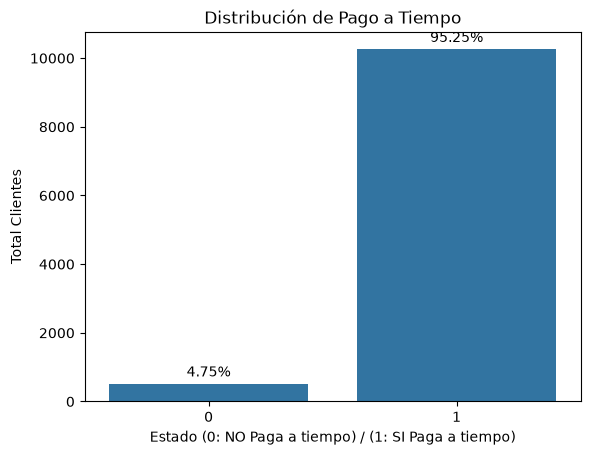

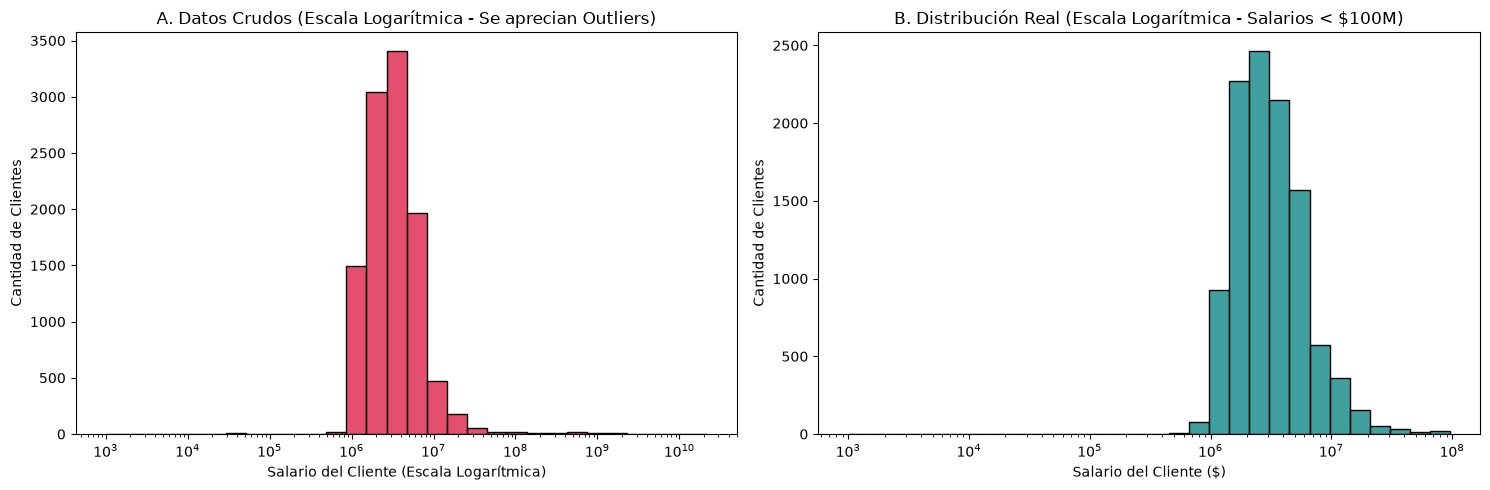

In [2]:
# 1. Confirmando clientes mayores a 90 años
print(f"Cantidad de clientes con más de 90 años:\n{df[df['edad_cliente'] > 90]['edad_cliente'].value_counts()}")
print("-"*100)

# 2. Confirmando datos en negativo para puntaje y puntaje_datacredito
print(f"Cantidad de clientes con puntaje negativo:\n{df[df['puntaje'] < 0]['puntaje'].value_counts()}")
print(f"Cantidad de clientes con puntaje_datacredito negativo:\n{df[df['puntaje_datacredito'] < 0]['puntaje_datacredito'].value_counts()}")
print("-"*100)

# 3. Confirmando salarios atípicos gigantescos (ej. mayores a 100 millones)
print(f"Cantidad de clientes con salarios atípicos extremados:\n{df[df['salario_cliente'] > 100000000]['salario_cliente'].value_counts()}")

# 4. Creando copia del DataFrame para análisis e imputaciones
df_copy = df.copy()
print(df_copy)
print("Se crea copia exitosa del DataSet")
print("-"*100)

# Revisando el desbalance de clases (cuántos pagan vs cuántos no)
print(df_copy['Pago_atiempo'].value_counts(normalize=True))
print("-"*100)

# Se imprime la magnitud de las anomalías
anomalias_edad = df_copy[df_copy['edad_cliente'] > 90].shape[0]
anomalias_puntaje = df_copy[df_copy['puntaje'] < 0].shape[0]
anomalias_salario = df_copy[df_copy['salario_cliente'] > 100_000_000].shape[0]

print(f"Total de registros atípicos detectados:")
print(f"- Edades irreales (>90 años): {anomalias_edad}")
print(f"- Puntajes internos negativos: {anomalias_puntaje}")
print(f"- Salarios extremos (>100M): {anomalias_salario}")
print("-"*100)

# Realizando graficas para ver el comportamiento de nuestro target
plt.figure()
ax = sns.countplot(data= df_copy, x= 'Pago_atiempo')
plt.title("Distribución de Pago a Tiempo")
plt.xlabel ("Estado (0: NO Paga a tiempo) / (1: SI Paga a tiempo)")
plt.ylabel ("Total Clientes")

# Porcentaje sobre las barras
ax.bar_label(
    ax.containers[0],
    fmt = lambda x: f"{(x/ len(df_copy))*100:.2f}%",
    padding = 3
)
plt.show()

# Grafica para visualizar el comportamiento de salario_cliente
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfica de Datos Crudos con Escala Logarítmica (Para no comprimir las barras)
sns.histplot(df_copy['salario_cliente'], bins=30, ax=axes[0], color='crimson', log_scale=True)
axes[0].set_title("A. Datos Crudos (Escala Logarítmica - Se aprecian Outliers)")
axes[0].set_xlabel("Salario del Cliente (Escala Logarítmica)")
axes[0].set_ylabel("Cantidad de Clientes")

# 2. Gráfica de Datos Filtrados con Escala Logarítmica (Distribución Real de la Mayoría)
salarios_filtrados = df_copy[df_copy['salario_cliente'] < 100_000_000]['salario_cliente']
sns.histplot(salarios_filtrados, bins=30, ax=axes[1], color='teal', log_scale=True)
axes[1].set_title("B. Distribución Real (Escala Logarítmica - Salarios < $100M)")
axes[1].set_xlabel("Salario del Cliente ($)")
axes[1].set_ylabel("Cantidad de Clientes")

plt.tight_layout()
plt.show()

### 📃 MANEJO DE VALORES NULOS, NEGATIVOS, ERRONEOS E IRRACIONALES.

### 🧹 Limpieza de Datos y Estrategias de Imputación
Se realizó la identificación visual y corrección de **valores nulos y anómalos (negativos y outliers)** sobre una copia del dataset (`df_copy`), aplicando criterios de negocio y técnicas grupales para preservar la distribución de la información.

### 📊 Diagnóstico de Valores Faltantes
Se generó un diagrama de barras horizontal para visualizar el porcentaje de nulos por variable antes del tratamiento, identificando a `tendencia_ingresos` (~27%) como la columna con mayor ausencia de datos.


### ⚙️ Estrategias de Tratamiento Aplicadas

1. **Edades Atípicas (`edad_cliente > 90`):** Se reemplazaron por `NaN` y se imputaron con la **mediana agrupada por `tipo_laboral`** para mantener la coherencia según la etapa del ciclo vital del cliente.
2. **Puntajes Negativos (`puntaje` y `puntaje_datacredito`):** Se convirtieron los valores `< 0` a `NaN` y se imputaron mediante la mediana global de cada indicador.
3. **Saldos en Mora (`saldo_mora`, `saldo_mora_codeudor`):** Los valores faltantes se imputaron con **`0`**, bajo el supuesto de negocio de que la ausencia de registro equivale a no presentar saldo vencido.
4. **Saldos Principales y Totales:** Imputados con la **mediana por `tipo_laboral`** para conservar la escala financiera asociada a cada perfil ocupacional.
5. **Ingresos y Tendencias:**
   * **`tendencia_ingresos` (Categórica):** Se imputaron los nulos con la etiqueta **`"Sin_Informacion"`** para no perder el volumen de datos ni sesgar las categorías existentes.
   * **`promedio_ingresos_datacredito`:** Imputado con la mediana segmentada por `tipo_laboral`.
6. **`salario_cliente`:** Se mantuvo en su estado original para el análisis exploratorio, dejando su tratamiento/filtrado condicionado a las pruebas de rendimiento en el *pipeline* de modelado.


### ✅ Resultado
Se confirmó un **conteo final de 0 valores nulos** en todas las columnas del dataset procesado, dejando los datos completamente acondicionados para las fases de análisis bivariado y preparación para Machine Learning.

C:\Users\deibe\AppData\Local\Temp\ipykernel_23136\3429935956.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_pct.values, y=nulos_pct.index, palette="Blues_r")


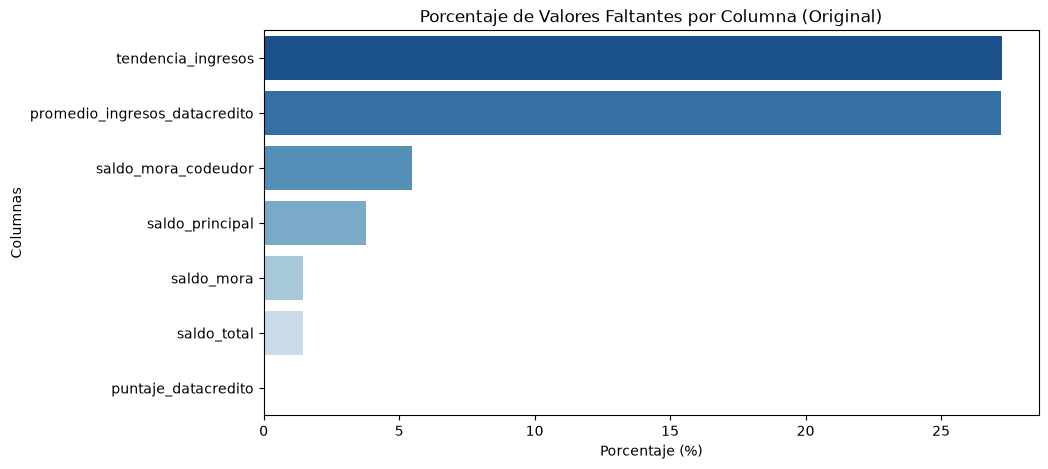

Conteo de nulos tras las imputaciones:
Series([], dtype: int64)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10763.000000,10763.000000,10763.000000,10763.000000,1.076300e+04,1.076300e+04,10763.000000,10763.000000,10763.000000,10763.000000,1.076300e+04,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,42.806002,1.721643e+07,6.238870e+06,2.436174e+05,92.502146,780.870668,5.726749,4.228561,7.633745,4.549509e+04,3.936145e+04,0.245749,2.779987,0.269813,1.302704,1.779820e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,0.050943,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,3.025000e+03,2.999000e+03,0.000000,1.000000,0.000000,0.000000,9.457240e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,41.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.565000e+04,1.376600e+04,0.000000,2.000000,0.000000,1.000000,1.147361e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,52.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.215600e+04,4.529700e+04,0.000000,4.000000,0.000000,2.000000,1.705770e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,69.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,11.868444,3.554767e+08,1.184183e+08,2.104937e+05,11.752393,104.573722,3.977162,3.064683,224.313390,1.055598e+05,7.006645e+04,21.167764,2.748807,0.716471,1.824430,1.870851e+06,0.212668


In [3]:
# Creación de grafica para ver el porcentaje de nulos por columna antes de realizar las imputaciones de valores nulos y negativos
nulos_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]

# Gráfica de porcentaje de nulos
plt.figure(figsize=(10, 5))
sns.barplot(x=nulos_pct.values, y=nulos_pct.index, palette="Blues_r")
plt.title("Porcentaje de Valores Faltantes por Columna (Original)")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Columnas")
plt.show()

# Realizamos el reemplazo de los valores nulos, y cancelamos los valores negativos

# 1. EDAD: Reemplazar > 90 por NaN e imputar por la mediana según 'tipo_laboral'
df_copy.loc[df_copy['edad_cliente'] > 90, 'edad_cliente'] = np.nan
df_copy['edad_cliente'] = df_copy.groupby('tipo_laboral')['edad_cliente'].transform(
    lambda x: x.fillna(x.median())
)

# 2. PUNTAJE: Convertir valores negativos a NaN
df_copy.loc[df_copy['puntaje'] < 0, 'puntaje'] = np.nan
df_copy['puntaje'] = df_copy['puntaje'].fillna(df_copy['puntaje'].median())

# 3. PUNTAJE_DATACREDITO: Convertir negativos a NaN y rellenar con la mediana global
df_copy.loc[df_copy['puntaje_datacredito'] < 0, 'puntaje_datacredito'] = np.nan
df_copy['puntaje_datacredito'] = df_copy['puntaje_datacredito'].fillna(df_copy['puntaje_datacredito'].median())

# 4. SALDOS EN MORA Y SALDOS PRINCIPALES:
# Saldos en mora imputados a 0
df_copy['saldo_mora'] = df_copy['saldo_mora'].fillna(0)
df_copy['saldo_mora_codeudor'] = df_copy['saldo_mora_codeudor'].fillna(0)

# Saldo total y principal imputados por la mediana según tipo laboral
df_copy['saldo_total'] = df_copy.groupby('tipo_laboral')['saldo_total'].transform(
    lambda x: x.fillna(x.median())
)
df_copy['saldo_principal'] = df_copy.groupby('tipo_laboral')['saldo_principal'].transform(
    lambda x: x.fillna(x.median())
)

# 5. SALARIO_CLIENTE: Se mantiene tal cual para el EDA, pero si se debe realizar cambios en el pipeline en caso
# En caso de que genere irregularidad en el entrenamiento de los modelos.

# 7. PROMEDIO_INGRESOS Y TENDENCIA_INGRESOS:
# Categorical: 'Sin_Informacion'
categorias_validas = ['Creciente', 'Decreciente', 'Estable']
# Reemplazamos los valores numéricos o cualquier valor no válido por "Sin_Informacion"
df_copy['tendencia_ingresos'] = df_copy['tendencia_ingresos'].apply(
    lambda x: x if x in categorias_validas else 'Sin_Informacion'
)


# Numerical: Mediana por tipo laboral
df_copy['promedio_ingresos_datacredito'] = df_copy.groupby('tipo_laboral')['promedio_ingresos_datacredito'].transform(
    lambda x: x.fillna(x.median())
)

# Verificación de nulos restantes
print("Conteo de nulos tras las imputaciones:")
print(df_copy.isnull().sum()[df_copy.isnull().sum() > 0])
df_copy.describe()

### 📐 Análisis Estadístico Univariado y Forma de la Distribución

Para evaluar la estructura individual de las variables numéricas tras el proceso de limpieza, se calcularon las métricas de tendencia central, dispersión y forma (asimetría y curtosis).

### 💡 Conceptos Clave de Forma
* **Asimetría (*Skewness*):** Mide qué tan desviada está la distribución respecto a una campana simétrica (Normal, donde *Skewness* = 0).
  * **Asimetría positiva (> 0):** La cola más larga está a la derecha. Indica que la mayoría de los datos son valores pequeños, pero existen casos atípicos extremadamente altos (ej. `salario_cliente`, `saldo_mora`).
  * **Asimetría negativa (< 0):** La cola se extiende hacia la izquierda (ej. `puntaje`, `puntaje_datacredito`), mostrando concentración de datos en la zona alta con algunos valores bajos.
* **Curtosis (*Kurtosis*):** Mide el nivel de concentración de los datos alrededor de la media y el grosor de las colas (presencia de valores extremos/outliers).
  * **Mesocúrtica (= 0 o cercana a 3 en escala absoluta):** Distribución normal.
  * **Leptocúrtica (> 0 o alta):** Presenta un pico muy pronunciado y colas pesadas llenas de outliers (ej. `salario_cliente` con curtosis de 2211.23).
  * **Platicúrtica (< 0):** Distribución aplastada y dispersa, con colas ligeras (ej. `edad_cliente` con curtosis de -0.83).

### 📊 Hallazgos Principales del Análisis Univariado
1. **Sesgo Severo por Outliers Financiales:**
   * Variables como `salario_cliente` (*skewness*: 43.77) y `total_otros_prestamos` (*skewness*: 38.46) presentan valores de curtosis superiores a **1700**, confirmando la presencia de colas extremadamente pesadas producidas por los montos astronómicos aún no escalados.
2. **Estructura de la Edad (`edad_cliente`):**
   * Tras la imputación, la variable presenta una media de **42.8 años**, una mediana de **41.0 años**, un sesgo muy leve (*skewness*: 0.27) y curtosis negativa (-0.83), indicando una **distribución uniforme y bien balanceada** entre los 19 y 69 años.
3. **Puntajes Crediticios Concetrados:**
   * Las variables `puntaje` y `puntaje_datacredito` presentan un **sesgo negativo** (-5.38 y -5.65) y elevada curtosis (> 30). Esto demuestra que la gran mayoría de la población evaluada se concentra en perfiles de score alto, con muy pocos casos en zonas de riesgo severo.

##### 1. Variables Categóricas
* **Ocupación (`tipo_laboral`):** La cartera se compone mayoritariamente por **Empleados (62.75%)**, seguidos por **Independientes (37.25%)**.
* **Comportamiento Financiero (`tendencia_ingresos`):** Casi la mitad de los clientes muestra una **tendencia creciente (49.19%)**, un **23.03%** se divide entre decreciente o estable, y un **27.78%** corresponde a registros categorizados como `"Sin_Informacion"`.

##### 2. Dispersión y Calificación Crediticia
* **Edad (`edad_cliente`):** Presenta una distribución acotada e ideal tras la limpieza, con una mediana centrada en los **41 años** y un rango que abarca desde los 19 hasta los 69 años.
* **Puntaje Interno (`puntaje`):** El gráfico de violín confirma que la inmensa mayoría de la población está agrupada en la zona de bajo riesgo (**entre 80 y 100 puntos**), lo cual guarda directa coherencia con la alta tasa de pago a tiempo observada en la cartera.

In [4]:
# Estadísticas descriptivas extendidas
stats_num = df_copy.describe().T
stats_num['varianza'] = df_copy.select_dtypes(include=[np.number]).var()
stats_num['IQR'] = stats_num['75%'] - stats_num['25%']
stats_num['skewness'] = df_copy.select_dtypes(include=[np.number]).skew()
stats_num['kurtosis'] = df_copy.select_dtypes(include=[np.number]).kurt()

# Mostrar la tabla descriptiva completa
stats_num[['mean', 'std', 'min', '50%', 'max', 'varianza', 'IQR', 'skewness', 'kurtosis']]

,mean,std,min,50%,max,varianza,IQR,skewness,kurtosis
tipo_credito,5.411131,2.338279,4.0,4.0,68.0,5.467548e+00,5.0,2.672074,46.464260
fecha_prestamo,2025-04-16 23:06:02.111121,NaN,2024-11-26 09:17:04,2025-03-27 16:23:12,2026-04-26 18:43:52,NaN,146 days 19:54:50.500000,NaN,NaN
capital_prestado,2434315.001319,1909642.758997,360000.0,1921920.0,41444152.8,3.646735e+12,1860009.0,3.723884,35.318092
plazo_meses,10.575583,6.632082,2.0,10.0,90.0,4.398451e+01,6.0,2.459691,7.780121
edad_cliente,42.806002,11.868444,19.0,41.0,69.0,1.408600e+02,19.0,0.279139,-0.830029
salario_cliente,17216431.459909,355476717.603482,0.0,3000000.0,22000000000.0,1.263637e+17,2875808.0,43.776664,2211.230120
total_otros_prestamos,6238869.648518,118418316.941069,0.0,1000000.0,6787675263.0,1.402290e+16,1500000.0,38.463886,1719.280871
cuota_pactada,243617.406671,210493.694608,23944.0,182863.0,3816752.0,4.430760e+10,166792.0,3.793301,26.650757
puntaje,92.502146,11.752393,0.050943,95.227787,95.227787,1.381187e+02,0.0,-5.380613,30.257018
puntaje_datacredito,780.870668,104.573722,0.0,791.0,999.0,1.093566e+04,68.0,-5.653315,39.627826


tipo_laboral
Empleado         62.752021
Independiente    37.247979
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
tendencia_ingresos
Creciente          49.187030
Sin_Informacion    27.780359
Decreciente        11.994797
Estable            11.037815
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------


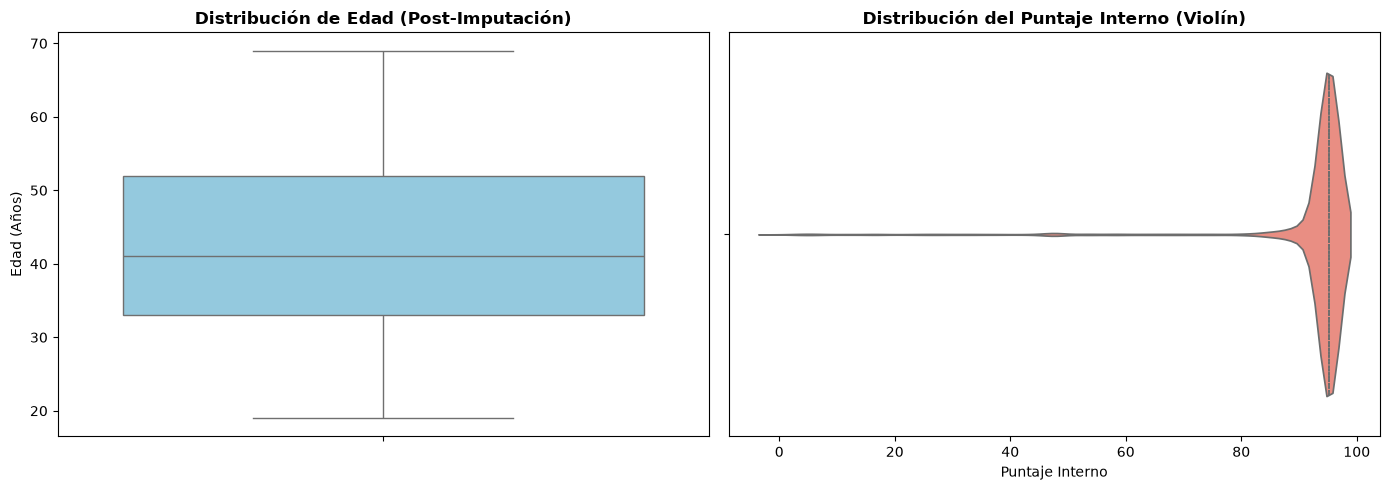

In [5]:
# Frecuencias para variables categóricas
print(df_copy['tipo_laboral'].value_counts(normalize=True) * 100)
print("-"*100)
print(df_copy['tendencia_ingresos'].value_counts(normalize=True) * 100)
print("-"*100)

# Gráficas de distribución y dispersión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot para la edad
sns.boxplot(data=df_copy, y='edad_cliente', ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad (Post-Imputación)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Edad (Años)')

# 2. Gráfico 2, Violín para puntaje
sns.violinplot(data=df_copy, x='puntaje', ax=axes[1], color='salmon', inner='quartile')
axes[1].set_title('Distribución del Puntaje Interno (Violín)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Puntaje Interno')

plt.tight_layout()
plt.show()

### 📈 Análisis Bivariado: Relación de Variables vs. Cumplimiento (`Pago_atiempo`)

##### 1. Variables Categóricas vs. Variable Objetivo
* **Tipo Laboral:** Los clientes **Empleados** presentan una tasa de pago a tiempo ligeramente superior en comparación con los **Independientes**, registrando estos últimos un sesgo hacia el incumplimiento de casi 1.2 puntos porcentuales más.
* **Tendencia de Ingresos:** Los clientes con **ingresos crecientes** son los más cumplidos. En contraste, los clientes con **ingresos decrecientes** presentan la mayor tasa de mora del grupo (**6.27%**).

##### 2. Variables Numéricas Clave vs. Variable Objetivo
* **Puntaje Interno:** Muestra una diferenciación radical. La población en mora (`0`) presenta una mediana de score cercana a **48 puntos** con amplia dispersión, mientras que la población al día (`1`) está comprimida en el tope superior (**~95 puntos**).
* **Puntaje DataCrédito:** A mayor score externo, menor tasa de mora. La mediana de los clientes al día ronda los **791 puntos**, superando sensiblemente a la mediana de los clientes en incumplimiento.
* **Edad del Cliente:** La población que paga a tiempo tiende a ser ligeramente mayor (mediana de **41 años**) frente a quienes caen en mora (mediana de **38 años**), sugiriendo que la madurez demográfica aporta estabilidad al cumplimiento.

##### 3. Capacidad Financiera y Montos vs. Variable Objetivo
* **Salario del Cliente:** No muestra una separación clara entre clases a nivel de tendencia central; los valores atípicos extremos (salarios astronómicos) se concentran mayoritariamente en la clase cumplida debido al volumen de datos.
* **Capital Prestado:** Presenta distribuciones de monto muy similares en ambos grupos. Sin embargo, la clase en incumplimiento (`0`) muestra una dispersión con valores atípicos en montos intermedios/altos, lo que sugiere que **el riesgo no depende únicamente del tamaño del préstamo**, sino del perfil crediticio previo.

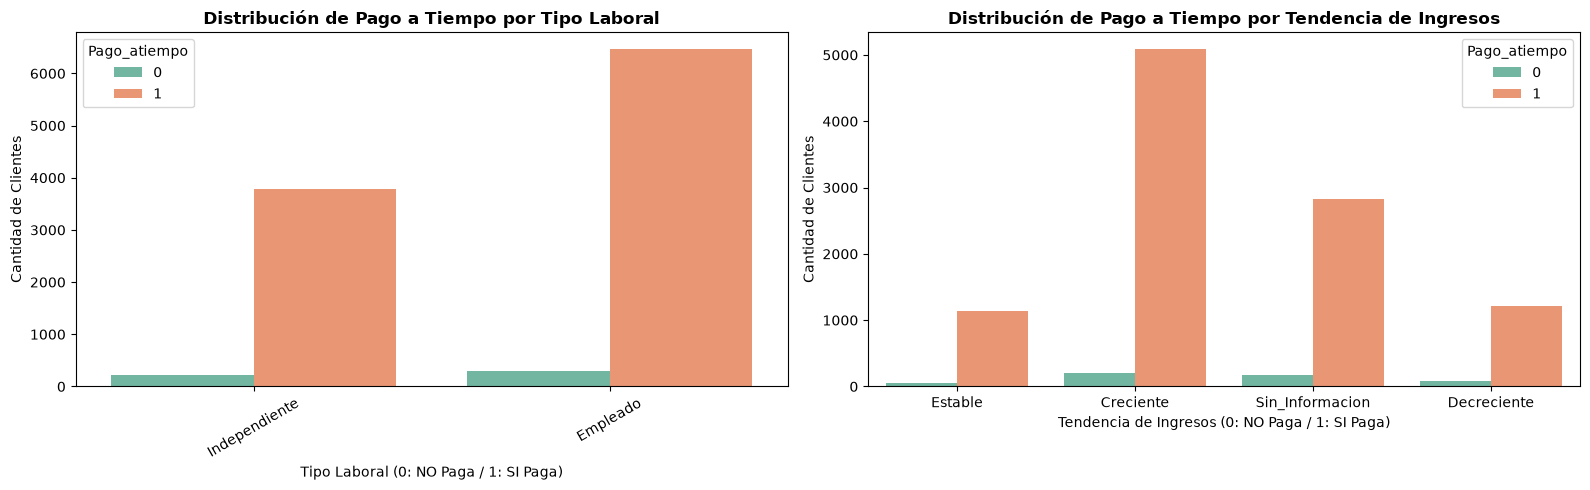

--- TASA DE PAGO A TIEMPO POR TIPO LABORAL (%) ---
Pago_atiempo          0          1
tipo_laboral                      
Empleado       4.293752  95.706248
Independiente  5.512597  94.487403


--- TASA DE PAGO A TIEMPO POR TENDENCIA DE INGRESOS (%) ---
Pago_atiempo               0          1
tendencia_ingresos                     
Creciente           3.910087  96.089913
Decreciente         6.274206  93.725794
Estable             4.629630  95.370370
Sin_Informacion     5.618729  94.381271


In [6]:
# Variables Categóricas vs. Variable Objetivo (Pago_atiempo)
# Se genera grafica relacional entre el porcentaje de mora segun el tipo de trabajo o tendencia de ingresos

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Tipo Laboral vs Pago a tiempo (Proporción / Frecuencia)
sns.countplot(data=df_copy, x='tipo_laboral', hue='Pago_atiempo', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Pago a Tiempo por Tipo Laboral', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo Laboral (0: NO Paga / 1: SI Paga)')
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].tick_params(axis='x', rotation=30)

# 2. Tendencia Ingresos vs Pago a tiempo
sns.countplot(data=df_copy, x='tendencia_ingresos', hue='Pago_atiempo', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Pago a Tiempo por Tendencia de Ingresos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tendencia de Ingresos (0: NO Paga / 1: SI Paga)')
axes[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

# Tablas cruzadas en porcentaje para análisis cuantitativo
print("--- TASA DE PAGO A TIEMPO POR TIPO LABORAL (%) ---")
print(pd.crosstab(df_copy['tipo_laboral'], df_copy['Pago_atiempo'], normalize='index') * 100)
print("\n" + "="*60 + "\n")
print("--- TASA DE PAGO A TIEMPO POR TENDENCIA DE INGRESOS (%) ---")
print(pd.crosstab(df_copy['tendencia_ingresos'], df_copy['Pago_atiempo'], normalize='index') * 100)

C:\Users\deibe\AppData\Local\Temp\ipykernel_23136\701058082.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='Pago_atiempo', y='puntaje', ax=axes[0], palette='Set2')
C:\Users\deibe\AppData\Local\Temp\ipykernel_23136\701058082.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='Pago_atiempo', y='puntaje_datacredito', ax=axes[1], palette='Set2')
C:\Users\deibe\AppData\Local\Temp\ipykernel_23136\701058082.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='Pago_atiempo', y='edad_cliente', a

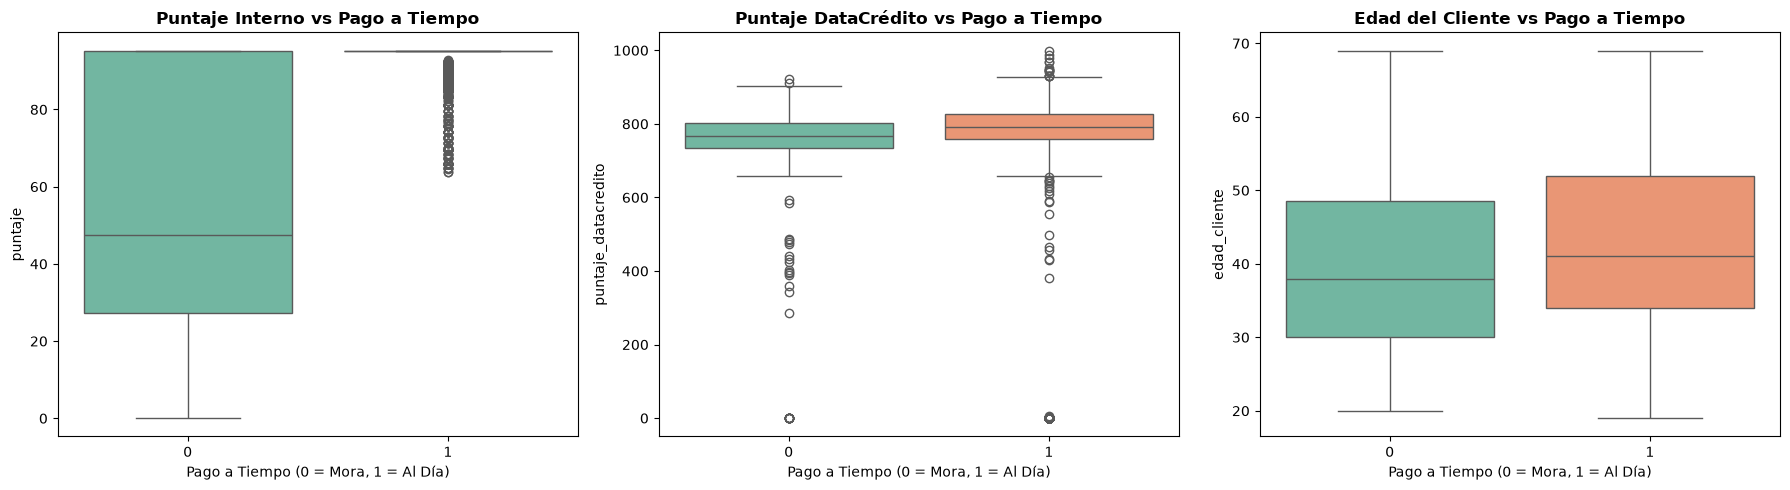

C:\Users\deibe\AppData\Local\Temp\ipykernel_23136\701058082.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='Pago_atiempo', y='salario_cliente', ax=axes[0], palette='Set2')
C:\Users\deibe\AppData\Local\Temp\ipykernel_23136\701058082.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x='Pago_atiempo', y='capital_prestado', ax=axes[1], palette='Set2')


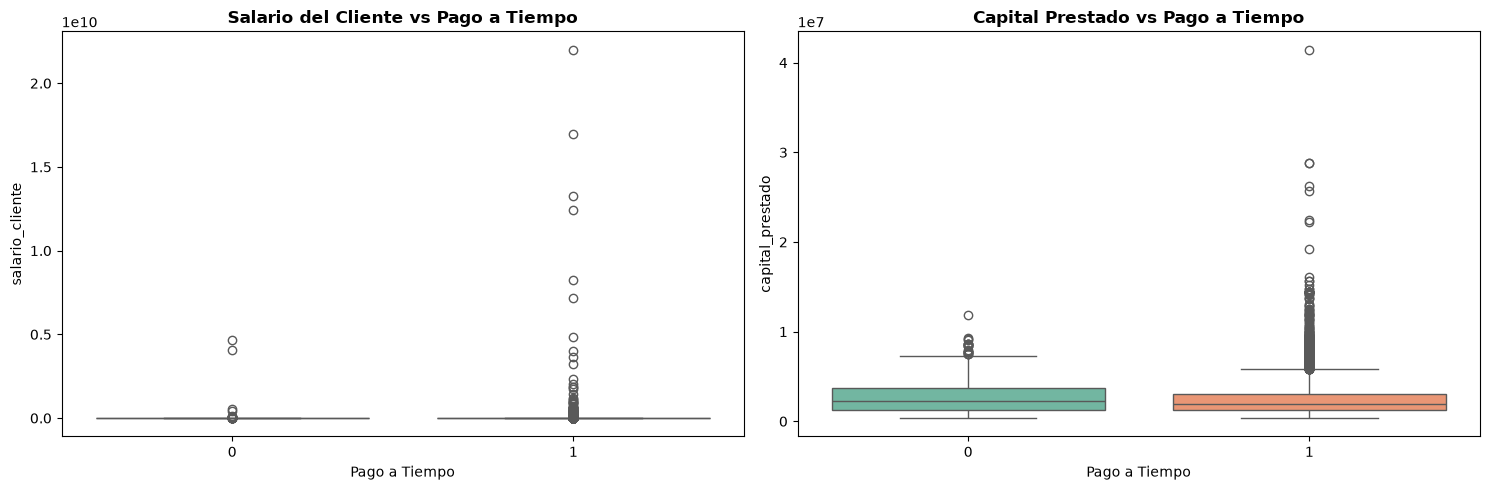

In [7]:
# Variables Numéricas Clave vs. Variable Objetivo (Comparación de Médias/Distribución)
# Se genera grafica para ver el scores de crédito (puntaje, puntaje_datacredito) o la edad_cliente cambian significativamente entre quienes pagan a tiempo y quienes entran en mora.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Puntaje Interno vs Pago a tiempo
sns.boxplot(data=df_copy, x='Pago_atiempo', y='puntaje', ax=axes[0], palette='Set2')
axes[0].set_title('Puntaje Interno vs Pago a Tiempo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pago a Tiempo (0 = Mora, 1 = Al Día)')

# 2. Puntaje DataCrédito vs Pago a tiempo
sns.boxplot(data=df_copy, x='Pago_atiempo', y='puntaje_datacredito', ax=axes[1], palette='Set2')
axes[1].set_title('Puntaje DataCrédito vs Pago a Tiempo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pago a Tiempo (0 = Mora, 1 = Al Día)')

# 3. Edad del Cliente vs Pago a tiempo
sns.boxplot(data=df_copy, x='Pago_atiempo', y='edad_cliente', ax=axes[2], palette='Set2')
axes[2].set_title('Edad del Cliente vs Pago a Tiempo', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Pago a Tiempo (0 = Mora, 1 = Al Día)')

plt.tight_layout()
plt.show()
# Capacidad Financiera vs. Variable Objetivo (Salario y Saldos)
# Grafica sobre montos de deuda o ingresos para mostrar alguna diferencia entre clases

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Salario del cliente por Estado de Pago
sns.boxplot(data=df_copy, x='Pago_atiempo', y='salario_cliente', ax=axes[0], palette='Set2')
axes[0].set_title('Salario del Cliente vs Pago a Tiempo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pago a Tiempo')

# 2. Capital Prestado por Estado de Pago
sns.boxplot(data=df_copy, x='Pago_atiempo', y='capital_prestado', ax=axes[1], palette='Set2')
axes[1].set_title('Capital Prestado vs Pago a Tiempo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pago a Tiempo')

plt.tight_layout()
plt.show()

### 🔗 Análisis Multivariado e Interacción de Variables

En esta sección se evalúa la interacción simultánea entre múltiples variables explicativas y su impacto conjunto sobre el comportamiento de cumplimiento (`Pago_atiempo`).

##### 1. Matriz de Correlación de Variables Numéricas
* **Correlación Directa con la Variable Objetivo (`Pago_atiempo`):** La variable con mayor fuerza predictiva lineal es **`puntaje`** con un coeficiente sobresaliente de **0.79**, confirmando que el score interno es el mejor predictor individual del cumplimiento.
* **Multicolinealidad Relevante:**
  * **`capital_prestado` vs `cuota_pactada` (0.76):** Fuerte relación lineal esperada; a mayor capital desembolsado, mayor es el valor de la cuota.
  * **`salario_cliente` vs `total_otros_prestamos` (0.60):** A mayor capacidad de ingreso, mayor es el nivel de endeudamiento global del cliente.
  * **`cant_creditosvigentes` vs Sectores Financiero/Real (0.54 - 0.79):** Alta redundancia entre el conteo total de créditos y la desagregación por sectores.

##### 2. Dispersión: Puntaje DataCrédito vs. Capital Prestado por Estado de Pago
* **Concentración de Riesgo:** Los clientes en incumplimiento (puntos rojos `0`) se distribuyen mayoritariamente en montos de capital inferiores a los **$10,000,000**, concentrándose en el rango de puntaje DataCrédito entre **650 y 850 puntos**.
* **Efecto de la Ausencia de Score:** Se observa un bloque de clientes con `puntaje_datacredito = 0` (sin historial o registro nulo) que lograron acceder a créditos de montos medios y altos, presentando una mezcla de clientes al día y en mora que requiere atención en las reglas de aprobación.

##### 3. Tabla Cruzada Multivariable (`tipo_laboral` x `tendencia_ingresos` x `Pago_atiempo`)
* **Mejor Perfil Combinado:** Los **Empleados con tendencia de ingresos Creciente** registran el desempeño de pago más alto del dataset con un **96.44% de cumplimiento**.
* **Perfil de Mayor Riesgo:** Los **Independientes con tendencia de ingresos Decreciente** representan el segmento con mayor índice de morosidad, registrando una caída en la tasa de pago a tiempo al **92.66%** (7.34% de mora).
* **Conclusión de Interacción:** La combinación de estabilidad laboral (empleado) e incrementos salariales (tendencia creciente) minimiza significativamente el riesgo crediticio.

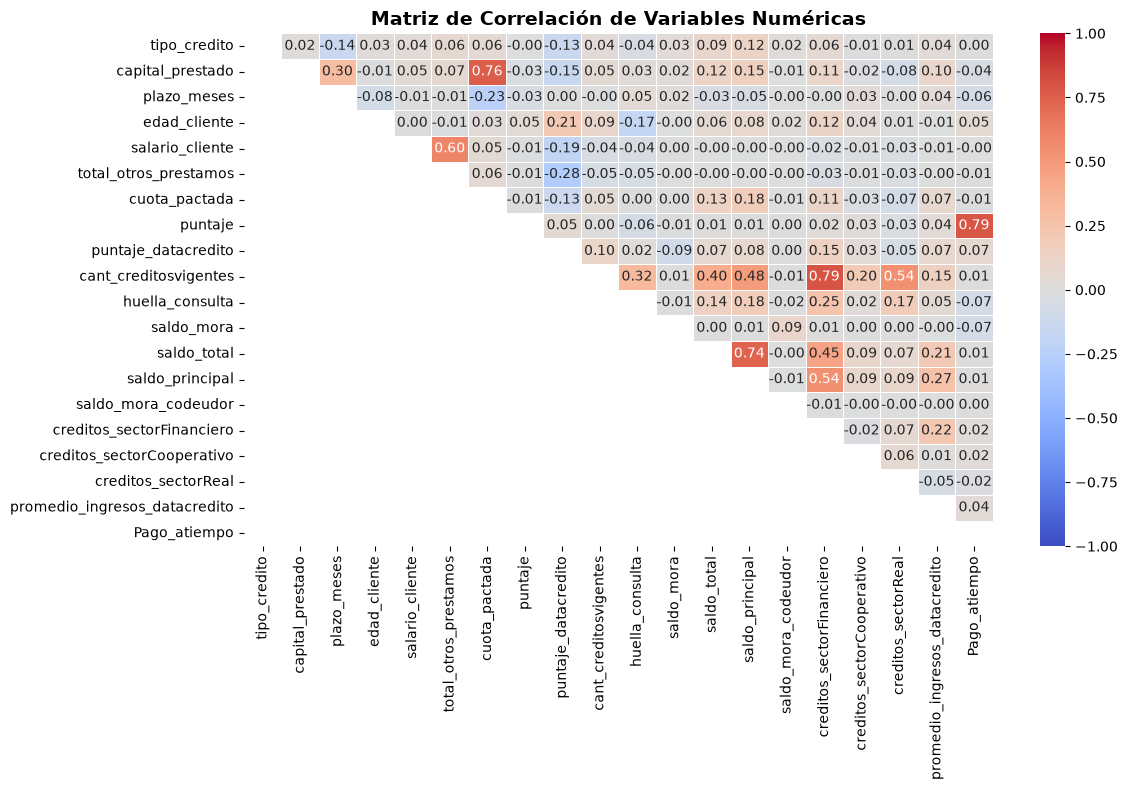

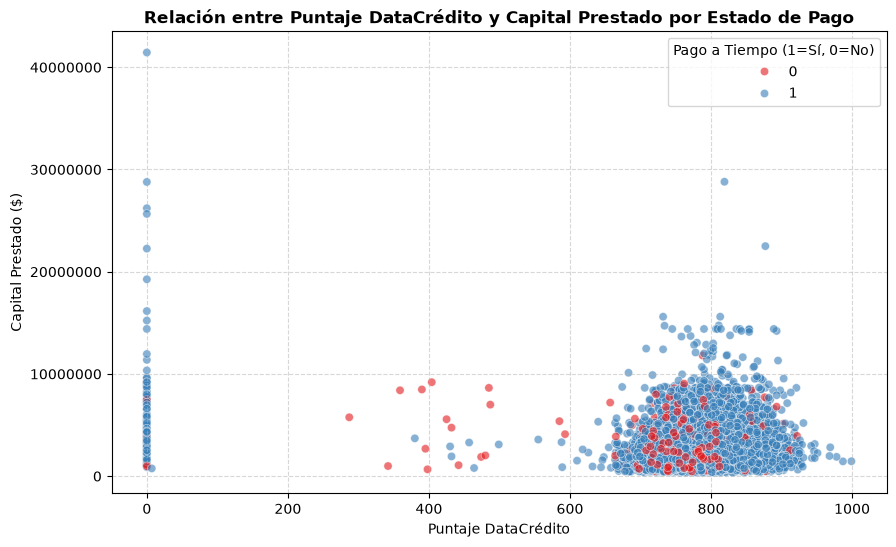

--- PORCENTAJE DE PAGO A TIEMPO (%) SEGÚN TIPO LABORAL Y TENDENCIA DE INGRESOS ---


tendencia_ingresos,Creciente,Decreciente,Estable,Sin_Informacion
tipo_laboral,,,,
Empleado,96.44,94.13,95.51,94.80
Independiente,95.18,92.66,95.20,94.04


In [13]:
# Relación de multivariables. 
# Primer paso: Matriz de Correlación - visualizar rápidamente todas las relaciones numéricas y verificar la colinealidad.

# 1. Matriz de Correlación
plt.figure(figsize=(12, 8))

# Seleccionar solo variables numéricas
cols_numericas = df_copy.select_dtypes(include=[np.number]).columns
corr_matrix = df_copy[cols_numericas].corr()

# Ocultando la cara de uno de los triangulos
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

# Dibujar Heatmap con paleta Divergente
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Para ver el comportamiento de la variable objetivo entre 2 variables claves en su predicción y que se visualiza relación entre sí
# puntaje_datacredito y capital_prestado

# 2. Scatterplot para relacion de 2 variables vs variable target
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_copy, 
    x='puntaje_datacredito', 
    y='capital_prestado', 
    hue='Pago_atiempo', 
    palette='Set1', 
    alpha=0.6
)

plt.title("Relación entre Puntaje DataCrédito y Capital Prestado por Estado de Pago", fontsize=12, fontweight='bold')
plt.xlabel("Puntaje DataCrédito")
plt.ylabel("Capital Prestado ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Pago a Tiempo (1=Sí, 0=No)")

# Formatear el eje Y para ver los valores monetarios claramente
plt.ticklabel_format(style='plain', axis='y')

plt.show()


# Tabla Cruzada Multivariable (Categoría x Categoría x Target)
# Interacción de las variables categoricas & variable target

# 3. Porcentaje de Pago a Tiempo (1) dividiendo por Tipo Laboral y Tendencia de Ingresos
multi_tab = pd.pivot_table(
    df_copy, 
    values='Pago_atiempo', 
    index='tipo_laboral', 
    columns='tendencia_ingresos', 
    aggfunc='mean'
) * 100

print("--- PORCENTAJE DE PAGO A TIEMPO (%) SEGÚN TIPO LABORAL Y TENDENCIA DE INGRESOS ---")
multi_tab.round(2)


### 🎯 Conclusión General del EDA y Hoja de Ruta para el Pipeline de Preprocesamiento

Este resumen consolida el estado del dataset y define las reglas de negocio e ingeniería de datos obligatorias que deben ser implementadas en el *pipeline* de preparación y durante el entrenamiento del modelo para la variable objetivo **`Pago_atiempo`**.

#### 1. Hallazgos Clave y Comportamiento de la Variable Objetivo
* **Desbalance Severo de Clientes:** La cartera presenta una distribución de **95.25% cumplidos (`1`) vs. 4.75% en mora (`0`)**. Es obligatorio implementar estrategias de rebalanceo (`class_weight='balanced'`, SMOTE o undersampling) y evaluar el modelo utilizando **PR-AUC, Recall y F1-Score** en lugar de *Accuracy*.
* **Variables de Mayor Poder Predictivo:** El **`puntaje` (score interno)** es la variable determinante ($r = 0.79$), seguida por el `puntaje_datacredito` y la `edad_cliente`.
* **Segmentos de Alto Riesgo:** Los **Independientes con tendencia de ingresos Decreciente** registran la mayor tasa de mora (7.34%), mientras que los **Empleados con ingresos Crecientes** son el segmento más seguro (96.44% de cumplimiento).

### 🧭 Guía Técnica para la Construcción del Pipeline de Preprocesamiento
Para replicar el tratamiento validado durante el EDA y evitar fuga de información (*data leakage*), el encargado del *pipeline* debe aplicar los siguientes pasos de transformación:

##### A. Tratamiento de Inconsistencias y Valores Anómalos (Filtros Previos)
* **`edad_cliente`:** Convertir valores anómalos (`> 90 años`) a `NaN`. Imputar utilizando la **mediana agrupada por `tipo_laboral`**.
* **`puntaje` y `puntaje_datacredito`:** Convertir cualquier valor negativo (`< 0`) a `NaN`. Imputar `puntaje` con la **mediana global** y `puntaje_datacredito` con su respectiva **mediana global**.

##### B. Imputación de Valores Faltantes (Nulos)
* **Saldos en Mora (`saldo_mora`, `saldo_mora_codeudor`):** Imputar los `NaN` directamente con **`0`** (ausencia de registro equivale a no presentar saldo vencido).
* **Saldos Financieros (`saldo_total`, `saldo_principal`):** Imputar los `NaN` utilizando la **mediana agrupada por `tipo_laboral`**.
* **Ingresos (`promedio_ingresos_datacredito`):** Imputar los `NaN` con la **mediana agrupada por `tipo_laboral`**.
* **Variables Categóricas (`tendencia_ingresos`):** Limpiar etiquetas no válidas o numéricas mapeando únicamente las categorías válidas (`['Creciente', 'Decreciente', 'Estable']`) e imputar nulos/inconsistencias bajo la categoría **`"Sin_Informacion"`**.

##### C. Transformación de Variables y Escalado para Machine Learning
* **Encoding de Categóricas:** 
  * `tendencia_ingresos` $\rightarrow$ Aplicar **Ordinal Encoding** (`Decreciente = 0`, `Estable = 1`, `Creciente = 2`, `Sin_Informacion` asignado a categoría neutral/separada).
  * `tipo_laboral` y `tipo_credito` $\rightarrow$ Aplicar **One-Hot Encoding** (`pd.get_dummies()`).
* **Tratamiento de Asimetría y Outliers:**
  * Variables con curtosis severa y sesgo positivo (`salario_cliente`, `total_otros_prestamos`, `capital_prestado`) requieren un **escalado robusto (`RobustScaler`)** o una **transformación logarítmica (`np.log1p`)** para evitar que los outliers distorsionen algoritmos sensibles a la distancia.
* **Reducción de Multicolinealidad:** Evaluar la eliminación o reducción de dimensionalidad en variables redundantes (`cuota_pactada` vs. `capital_prestado`, y desglose de créditos por sectores vs. `cant_creditosvigentes`).